Installing:

In [1]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


Downloading the dataset:

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="DFRAPJ5ad6Ubpu6wZEj3")
project = rf.workspace("kareems-workspace-1tyaf").project("seats-detection-lfkct")
version = project.version(3)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Seats-Detection-3 in yolov8:: 100%|██████████| 1223/1223 [00:00<00:00, 7139.81it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Trainging the dataset:

In [3]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/Seats-Detection-3/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='seats_detection_v3'
)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Seats-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seats_detection_v3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

Validate the dataset:

In [4]:
metrics = model.val()
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1181.4±765.6 MB/s, size: 35.5 KB)
val: Scanning /content/Seats-Detection-3/valid/labels.cache... 116 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 116/116 44.2Mit/s 0.0s
val: /content/Seats-Detection-3/valid/images/available_001_jpg.rf.7502cbb27e089d748941dad71ee2d4d9.jpg: 1 duplicate labels removed
val: /content/Seats-Detection-3/valid/images/available_035_jpg.rf.d7dc31ca21b93e8babd3c8951fbcc580.jpg: 1 duplicate labels removed
val: /content/Seats-Detection-3/valid/images/available_038_jpg.rf.6c5a0ef941cf3b67c907ed660a596022.jpg: 1 duplicate labels removed
val: /content/Seats-Detection-3/valid/images/available_048_jpg.rf.0d3650e10bba0bc1588caf0fae666a42.jpg: 1 duplicate labels removed
val: /content/Seats-Detection-3/valid/images/available_052_jpg.rf.7f3ab26993da2aa531e32

Demo:

Saving available_090.jpg to available_090.jpg

image 1/1 /content/available_090.jpg: 640x512 70 availables, 39.6ms
Speed: 2.6ms preprocess, 39.6ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)
Results saved to /content/runs/detect/predict


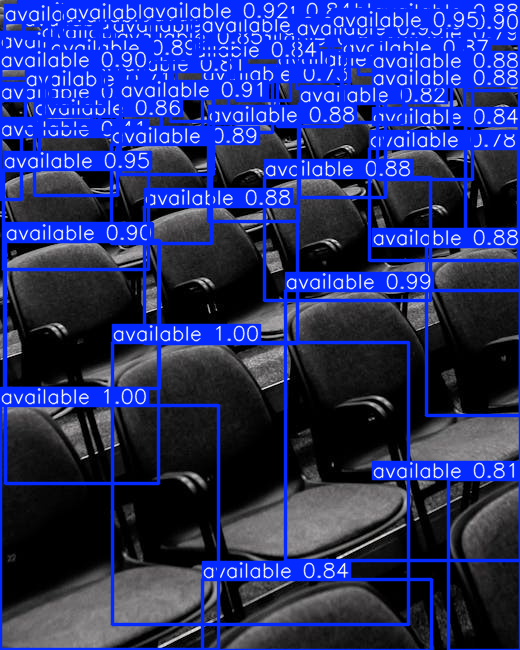

In [8]:
# Upload a test image first via the file panel on the left
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]

results = model.predict(filename, save=True, conf=0.4)
results[0].show()

Downlading the results:

In [ ]:
!zip -r /content/training_results_v3.zip /content/runs/detect/seats_detection_v3
from google.colab import files
files.download('/content/training_results_v3.zip')
files.download('/content/runs/detect/seats_detection_v3/weights/best.pt')